# TP 1 - Séance 2
## Rehaussement d'image

Équipe #0
- Nom, Prénom (Matricule)
- Nom, Prénom (Matricule)

<span style='color: red;'>
Si la prochaine cellule ne s'exécute pas, c'est qu'il vous manque probablement l'installation de certains packages. Assurez-vous que vous avez dans votre environnement conda les packages listés ici. 
    
Vous pouvez vérifier toutes les installations depuis un terminal Anaconda en activant votre environnement (`conda activate gbm8770`) puis en tapant la commande `conda list` ou `pip list`. 

Si vous ne voyez pas les packages dans la liste ainsi obtenue, vous pouvez les installer avec la commande `pip install package`, en remplaçant le nom du package par celui désiré. 

Attention : le package skimage s'appelle `scikit-image`, il faut donc l'installer avec `pip install scikit-image`. On l'importe ensuite tel qu'écrit dans la prochaine cellule (```import skimage```).

Vous aurez aussi à installer le package `openpyxl` pour vous permettre de charger des fichiers Excel.
</span>

In [3]:
# Importe les modules qui seront utilisés dans le laboratoire.
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
from scipy.ndimage import convolve
import skimage.filters as skfilters
import skimage.morphology as skmorph

from cv2 import cvtColor, COLOR_RGB2GRAY
from cv2 import imread as cv2Imread

import os
import pandas as pd
import skimage.draw as drw

%matplotlib inline
# Étend la taille des figures
plt.rcParams["figure.figsize"] = (12, 7)

# Exercice III: Prétraitement d'images grayscale

<font color='red'> Dans toutes les questions de cet exercice, prenez soin de spécifier les bornes des intensités lors de l'affichage. Voir énoncé en pdf. \
Tous les fichiers et les images dont vous aurez besoin pour cette séance sont dans le dossier 'fichiers_seance_2'. Vos chemins devront être ajustés en conséquence. 
</font>

## Égalisation d'histogramme

**1.** Ouvrez, convertissez en valeurs entières et affichez l'image ```radio_thoracique.png```.
Prenez soin de spécifier les bornes des intensités lors de l'affichage.

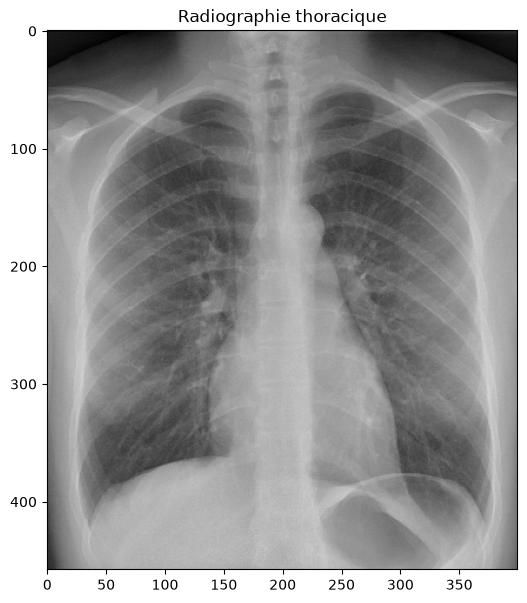

In [6]:
img_radio = plt.imread('radio_thoracique.png')

img_radio = (img_radio * 255).astype(int)

plt.imshow(img_radio, cmap='gray', vmin=0, vmax=255)
plt.title("Radiographie thoracique")
plt.show()

**2.** À l'aide de [np.histogram](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html), calculez puis affichez son histogramme.  
Pour gagner du temps aux questions suivantes, vous pouvez définir une fonction qui effectue ces deux opérations.

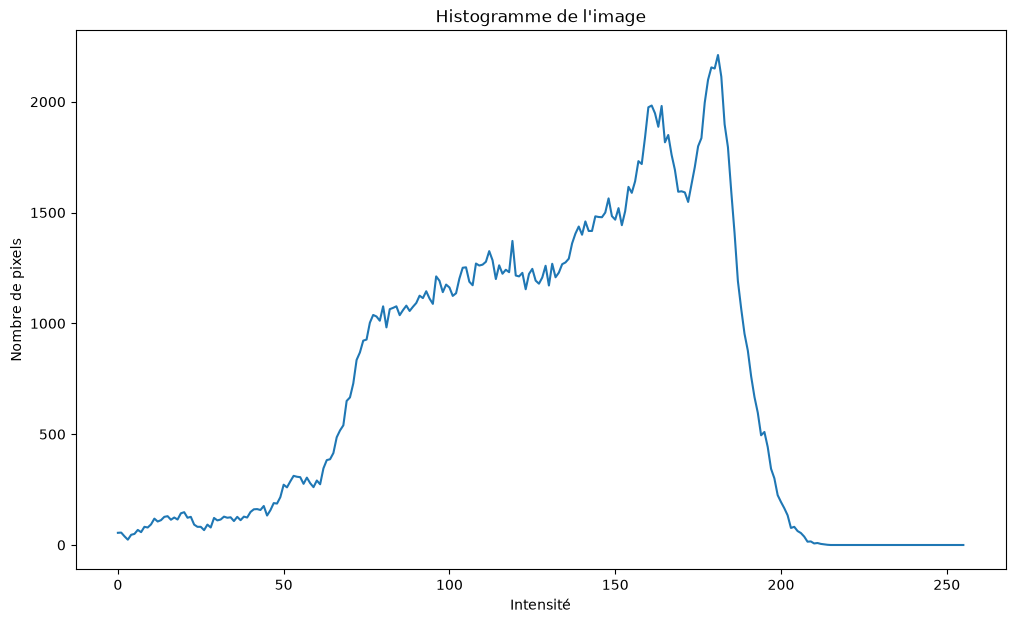

In [7]:
def afficher_histogramme(img):
    hist, bins = np.histogram(img, bins=256, range=(0, 256))

    plt.plot(bins[:-1], hist)
    plt.xlabel("Intensité")
    plt.ylabel("Nombre de pixels")
    plt.title("Histogramme de l'image")
    plt.show()

afficher_histogramme(img_radio)

**3a.** Complétez la fonction ```equalize_histogram(img)``` qui effectue l'égalisation d'histogramme d'une image `img` et renvoie l'image égalisée.

In [8]:
def equalize_histogram(img):

    # Calculer l'histogramme de l'image
    hist, _ = np.histogram(img, bins=256, range=(0, 256))

    # Calculer l'histogramme cumulé
    hist_cum = np.cumsum(hist)

    # Normaliser l'histogramme cumulé entre 0 et 255
    T = 255 * hist_cum / hist_cum[-1]

    # Convertir les nouvelles intensités en entiers
    T = T.astype(np.uint8)

    # Appliquer le mapping à tous les pixels
    img_eq = T[img]

    return img_eq


**3b.** Comparez l'image et son histogramme avant et après l'égalisation. Prenez soin de spécifier les bornes des intensités lors de l'affichage. Que constatez vous? Quel impact a l'égalisation sur le contraste de l'image?

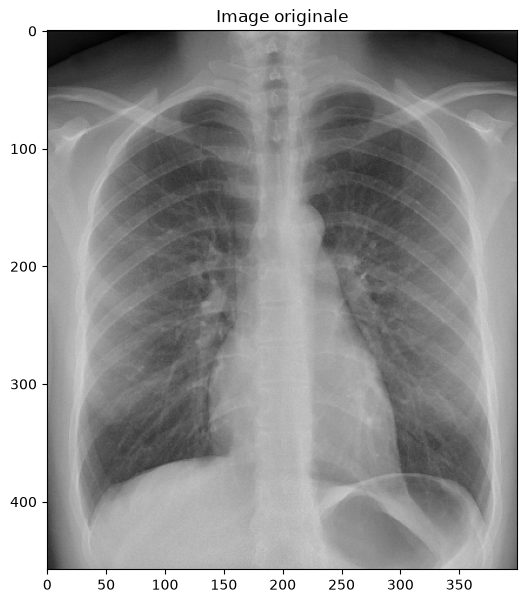

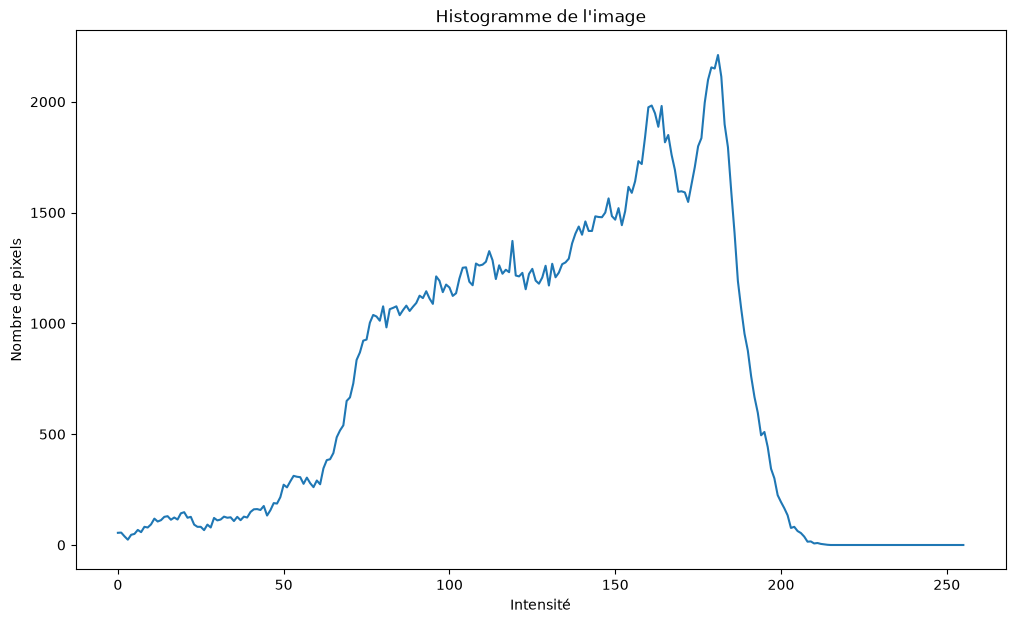

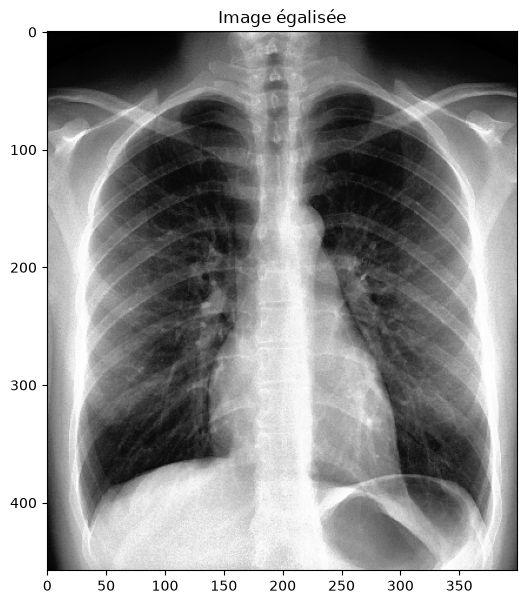

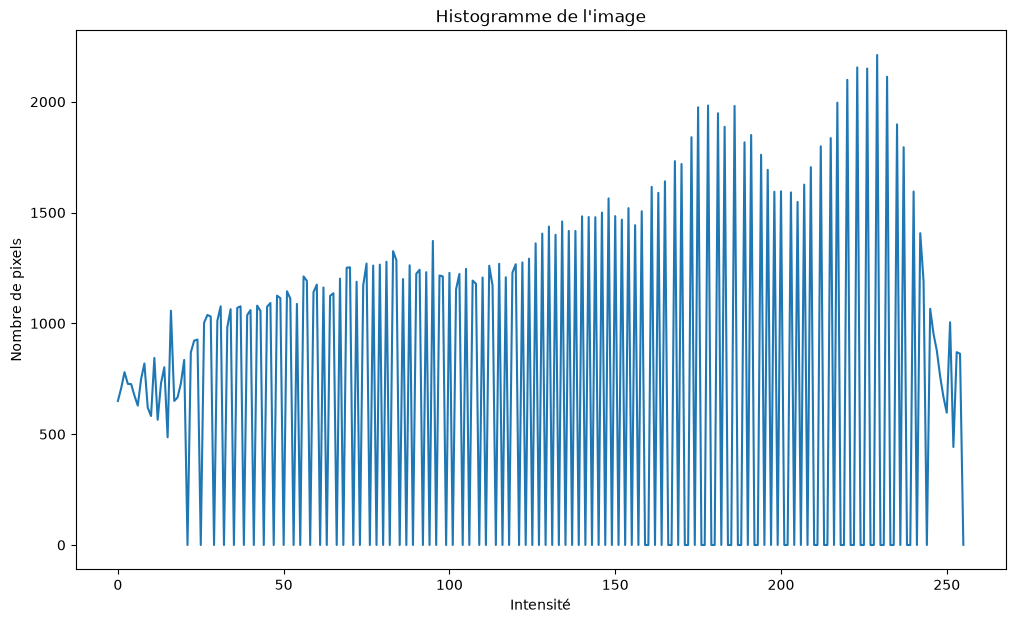

In [9]:
# Égaliser l'image
img_eq = equalize_histogram(img_radio)

# Image originale
plt.imshow(img_radio, cmap='gray', vmin=0, vmax=255)
plt.title("Image originale")
plt.show()

afficher_histogramme(img_radio)

# Image égalisée
plt.imshow(img_eq, cmap='gray', vmin=0, vmax=255)
plt.title("Image égalisée")
plt.show()

afficher_histogramme(img_eq)

**4.** Effectuez les mêmes opérations qu'à la question **3b** (égalisation d'histogramme puis affichage de l'image et l'histograme avant et après l'égalisation) sur l'image `fundus_mauvais_contraste`. Que constatez-vous ? Que proposeriez-vous afin d'améliorer le contraste et la visibilité des structures de l'oeil dans cette image ?

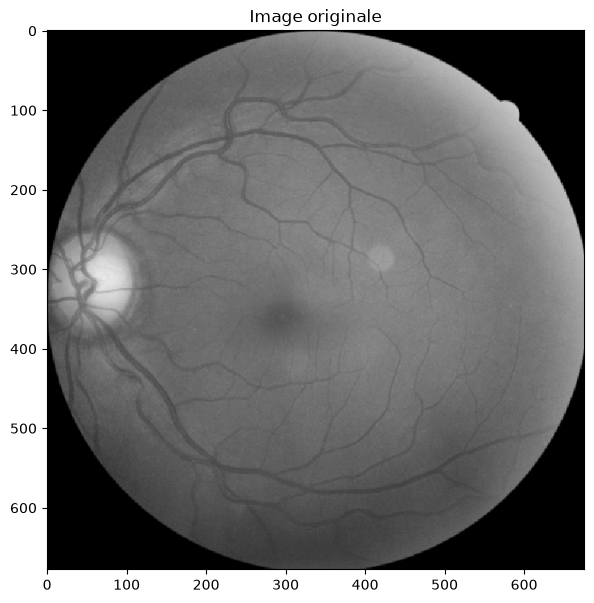

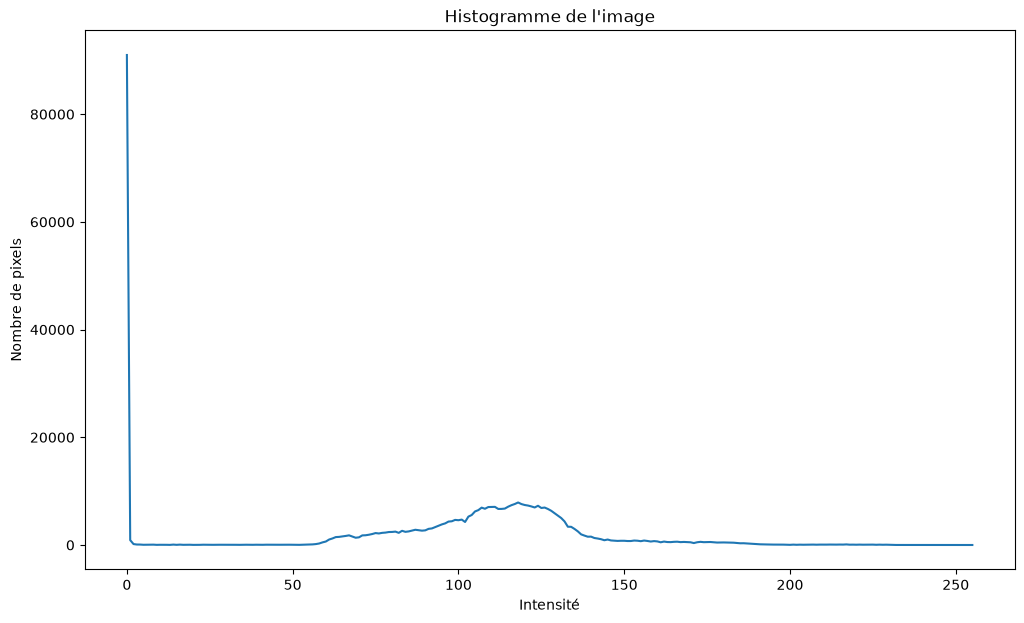

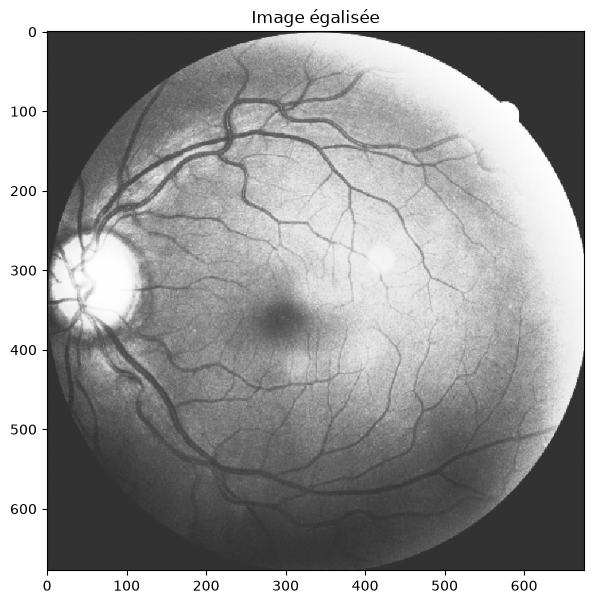

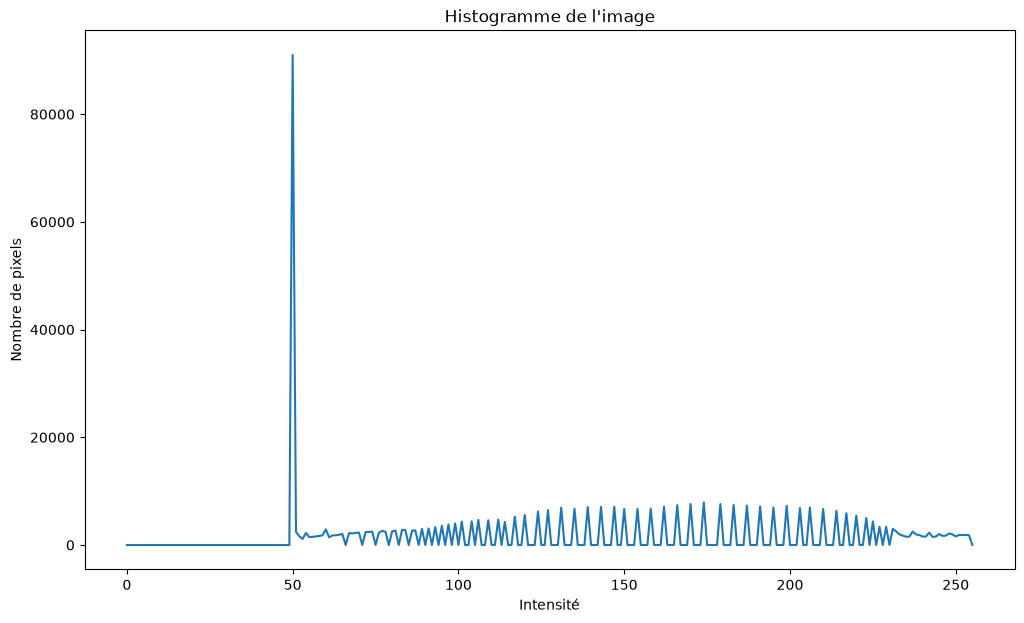

In [11]:
# Charger l'image et la convertir en niveaux de gris
image = cv2Imread("fundus_mauvais_contraste.png")
gray = cvtColor(image, COLOR_RGB2GRAY)

# Égaliser l'image
gray_eq = equalize_histogram(gray)

# Afficher l'image originale
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title("Image originale")
plt.show()

# Afficher l'histogramme original
afficher_histogramme(gray)

# Afficher l'image égalisée
plt.imshow(gray_eq, cmap='gray', vmin=0, vmax=255)
plt.title("Image égalisée")
plt.show()

# Afficher l'histogramme égalisé
afficher_histogramme(gray_eq)

#Après l’égalisation, le contraste est plus élevé et les vaisseaux sont plus visibles. Cependant, le bruit est aussi beaucoup plus apparent et certaines zones deviennent trop claires. 
#Une égalisation locale pourrait être utilisée pour améliorer le contraste des différentes régions de l’image sans autant amplifier le bruit.

## Filtrage High-Boost

**5.** Ouvrez l'image ```angiography.jpg```. Convertissez l'image en valeurs flottantes (normalisez par la valeur maximale) et conservez uniquement le premier canal de cette image. Affichez l'image résultante. 

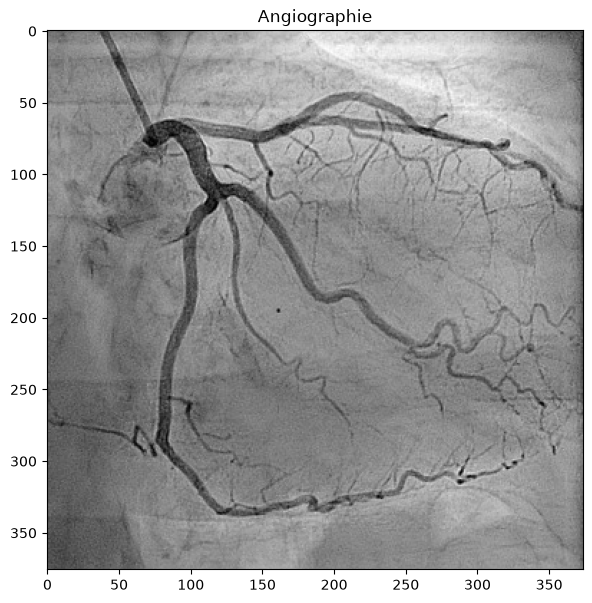

In [12]:
img_angio = plt.imread("angiography.jpg")

# Conversion en valeurs flottantes et normalisation
img_angio = img_angio.astype(float)
img_angio = img_angio / np.max(img_angio)

# Garder uniquement le premier canal
img_angio = img_angio[:, :, 0]

# Afficher l'image
plt.imshow(img_angio, cmap="gray", vmin=0, vmax=1)
plt.title("Angiographie")
plt.show()

**6.** En utilisant la fonction [convolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html), calculez la convolution de l'image angiographique avec une filtre gaussien de taille $3 \times 3$: 

$W_{Gaussienne3}\ =\ \dfrac{1}{16}\ \begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix} $

Affichez côte à côte l'image angiographique et le résultat de la convolution.

_N'hésitez pas à augmenter la taille de la figure pour mieux observer les images.)_

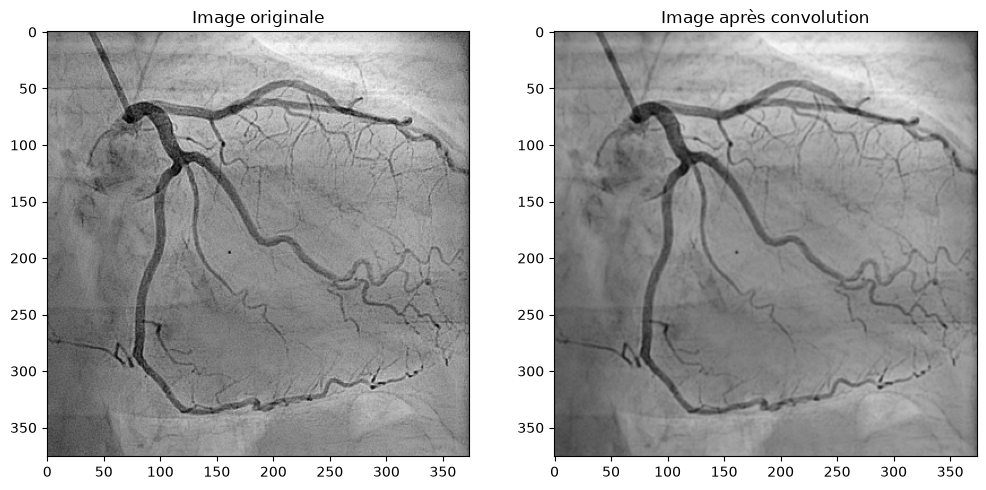

In [13]:
# On vous donne le masque de convolution:
Wgaussienne3 = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
# Appliquer la convolution avec le filtre gaussien
img_convolution = convolve(img_angio, Wgaussienne3)

# Afficher les deux images côte à côte
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_angio, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Image originale")

ax[1].imshow(img_convolution, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Image après convolution")

plt.show()

**7a.** Effectuez la même opération (convolution et affichage) avec une Gaussienne de taille 7x7: 

$W_{Gaussienne7}\ =\ \dfrac{1}{1115}\ 
\begin{bmatrix} 
 1 &  4 &  7 & 10 &  7 &  4 &  1 \\
 4 & 12 & 26 & 33 & 26 & 12 &  4 \\
 7 & 26 & 55 & 71 & 55 & 26 &  7 \\
10 & 33 & 71 & 91 & 71 & 33 & 10 \\
 7 & 26 & 55 & 71 & 55 & 26 &  7 \\
 4 & 12 & 26 & 33 & 26 & 12 &  4 \\
 1 &  4 &  7 & 10 &  7 &  4 &  1 \\
\end{bmatrix} $


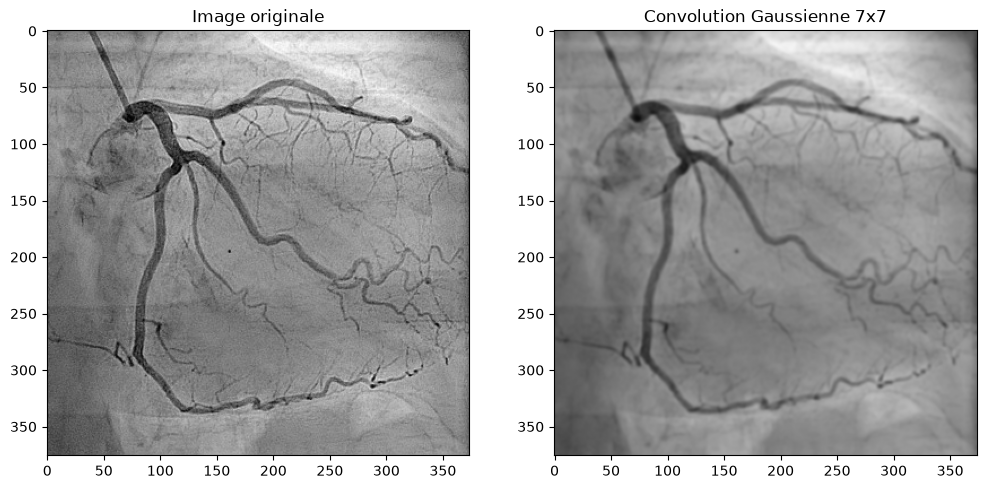

In [14]:
# On vous donne le masque de convolution:
Wgaussienne7 = (
    np.array(
        [
            [1, 4, 7, 10, 7, 4, 1],
            [4, 12, 26, 33, 26, 12, 4],
            [7, 26, 55, 71, 55, 26, 7],
            [10, 33, 71, 91, 71, 33, 10],
            [7, 26, 55, 71, 55, 26, 7],
            [4, 12, 26, 33, 26, 12, 4],
            [1, 4, 7, 10, 7, 4, 1],
        ]
    )
    / 1115
)

img_convolution7 = convolve(img_angio, Wgaussienne7)

# Afficher les deux images côte à côte
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_angio, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Image originale")

ax[1].imshow(img_convolution7, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Convolution Gaussienne 7x7")

plt.show()

**7b.** Qu'observez vous lorsque l'écart-type de la gaussienne augmente ?  Quel est le type de ces deux filtres gaussiens?

In [ ]:
#Lorsque l’écart-type de la gaussienne augmente, le lissage devient plus important. L’image devient donc plus floue et certains détails fins sont atténués.
#Les deux filtres gaussiens sont des filtres passe-bas, puisqu’ils atténuent les hautes fréquences, comme les détails fins et les variations rapides d’intensité.

**8a.** Calculez et affichez le Laplacien de l'image angiographique en la convoluant avec:

$W_{Laplacien}\ =\
\begin{bmatrix} 
 -1 & -1 & -1 \\
 -1 & 8 & -1 \\
 -1 & -1 & -1 \\
\end{bmatrix} $

_(Attention: le Laplacien d'une image contient des valeurs négatives, pour les visualiser correctement les bornes d'affichages doivent être -1 et 1!)_

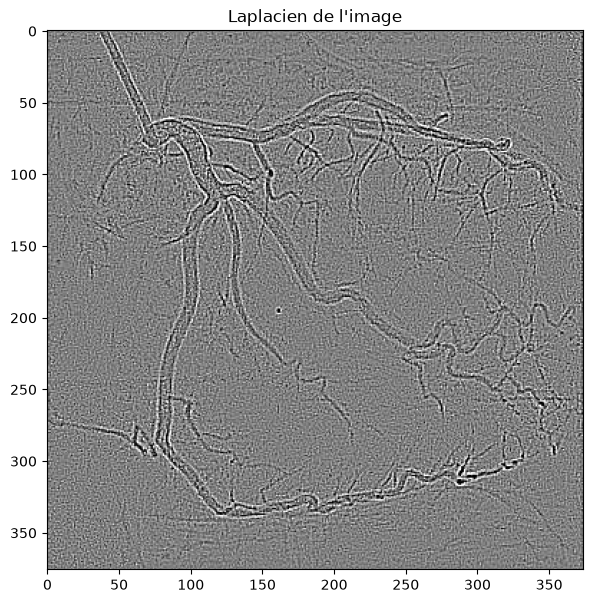

In [15]:
# On vous donne le masque de convolution:
Wlaplacien = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
# Calcul du Laplacien
img_laplacien = convolve(img_angio, Wlaplacien)

# Affichage du résultat
plt.imshow(img_laplacien, cmap="gray", vmin=-1, vmax=1)
plt.title("Laplacien de l'image")
plt.show()

**8b.** Quel est le type de ce filtre?

In [ ]:
#Le filtre laplacien est un filtre passe-haut, car il met en évidence les variations rapides d’intensité et donc les contours et les détails de l’image.

On rappelle que le filtrage high-boost est défini par:  
  $I_{g} =  I * W_{gaussienne3}$  
  $I_{HighBoost} = I + k \times (I_g * W_{laplacien})$  
  (avec $I$ l'image originale, $I_{HighBoost}$ l'image filtrée, et $I* _{gaussienne3}$ la convolution entre l'image et le masque gaussien de taille $3 \times 3$.)

**9a.** Implémentez la fonction `high_boost(img, k)` qui prend en paramètre l'image $I$ et $k$ et renvoie l'image après le filtrage High Boost. Affichez le résultat pour $k=0$, $k=1$ et $k=2$.  (Limitez l'affichage entre 0 et 1!)


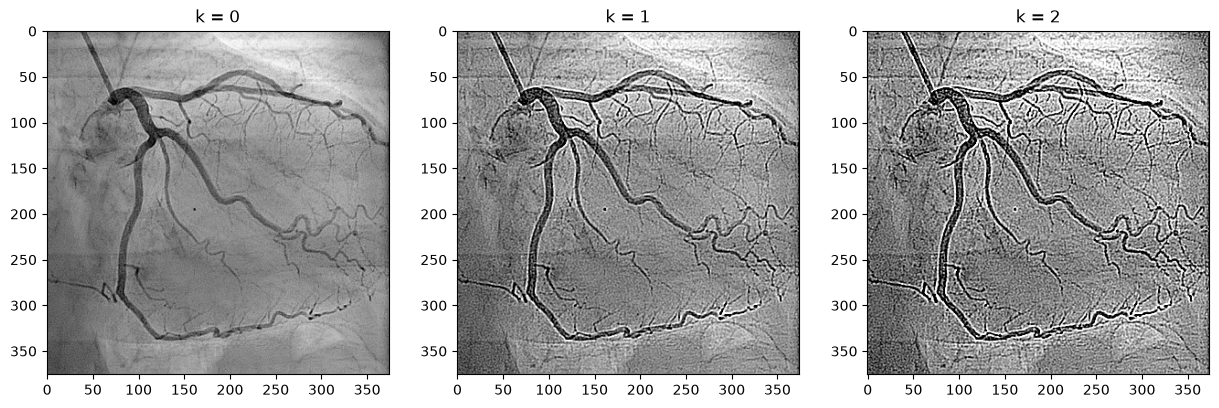

In [16]:
def high_boost(img, k):
    # Appliquer le filtre gaussien 3x3
    Ig = convolve(img, Wgaussienne3)

    # Calculer le Laplacien de l'image lissée
    laplacien = convolve(Ig, Wlaplacien)

    # Appliquer le filtrage High-Boost
    img_high_boost = img + k * laplacien

    return img_high_boost


# Calculer les résultats pour k = 0, 1 et 2
img_k0 = high_boost(img_angio, 0)
img_k1 = high_boost(img_angio, 1)
img_k2 = high_boost(img_angio, 2)

# Afficher les résultats
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_k0, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("k = 0")

ax[1].imshow(img_k1, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("k = 1")

ax[2].imshow(img_k2, cmap="gray", vmin=0, vmax=1)
ax[2].set_title("k = 2")

plt.show()

**9b.** Discutez de l'impact du facteur $k$ sur la lisibilité de l'image (et donc la qualité du réhaussement).

In [ ]:
#Lorsque k augmente, les contours et les détails deviennent plus visibles. Pour k=1, l’image est plus nette et les vaisseaux ressortent mieux. 
#Pour k=2, le rehaussement est plus fort, mais le bruit devient aussi beaucoup plus visible. Une valeur de k trop élevée peut donc diminuer la qualité de l’image.

**9c.** Dans ce filtrage, pourquoi calculer le laplacien sur $I_g$ plutôt que sur $I$ directement?  
_(Appuyez-vous sur vos observations de la question 7b.)_

In [ ]:
#Comme observé à la question 7b, le filtre gaussien est un filtre passe-bas qui lisse l’image et atténue les petites variations, dont le bruit. On calcule donc le Laplacien sur Ig, l’image déjà lissée, plutôt que directement sur l’image originale. 
#Comme le Laplacien est sensible aux variations rapides d’intensité, l’appliquer directement sur I ferait aussi ressortir le bruit. Le filtrage gaussien permet donc de réduire ce bruit avant de rehausser principalement les contours et les structures importantes de l’image.

# Exercice IV: Filtrage Médian et Morphologique

Cet exercice met en oeuvre des filtrages médians et morphologiques qui sont implémentés dans les modules pythons:   
```skimage.morphology``` et ```skimage.filters``` importé sous les noms: ```skmorph``` et ```skfilters``` (déjà importés dans la première cellule du notebook).

## Élimination du bruit par filtrage médian

**1a.** Chargez (sans conversion en intensités entières) et affichez l'image ```fundus_bruit.png```.

**1b.** Quel est le nom du bruit qui déteriore cette image de la rétine?

Pour la suite de l'exercice nous ne nous intéresserons qu'au canal vert de l'image.

**2.** Filtrez le bruit identifié à la question précédente à l'aide d'un filtrage médian [skfilters.median](https://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.median). Utilisez un élément structurant sous forme d'un disque (voir [skmorph.disk](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.disk)). Trouvez un rayon de disque approprié pour le filtrage. Affichez côte à côte le canal vert de l'image avant et après le filtrage.

**3.** Filtrez le bruit identifié à la question précédente avec les filtres gaussiens utilisés à l'exercice précédent (convolution de l'image avec un filtre gaussien). Le filtrage gaussien présenté dans l'exercice I aurait-il été un meilleur ou moins bon choix pour cette tâche ? Pourquoi ?

Les traitements présentés dans les deux sections suivantes seront appliqués sur **la version filtrée du canal vert** de l'image notée $I_V$.

## Réhaussement des vaisseaux

Afin de simplifier la détection des vaisseaux sur les images de la rétine, un prétraitement très utilisé consiste à effectuer une correction d'illumination locale. En définissant $F_{m}$ un filtre médian avec un large élément structurant (un disque de rayon 12), l'image prétraitée $I_P$ est calculée par: $I_P = I_V - F_m(I_V)$.

**4a.** Calculez et affichez le résultat du filtrage médian $F_{m}(I_V)$ et du prétraitement $I_P$. Cette correction d'illumination est-elle efficace?


**4b.** Les vaisseaux sont-ils un contenu hautes ou basses fréquences spatiales? Même question pour le résultat du filtrage médian $F_{m}(I_V)$.

## Segmentation du disque optique

On se propose de segmenter le disque optique (la tête du nerf optique apparaissant en clair sur l'image et dont émerge les vaisseaux) avec un seuil et des opérations morphologiqes.

**5a.** Implémentez la fonction ```binariser(img, seuil)``` qui prend en paramètre une image et un seuil et qui renvoie l'image binarisée: où tous les pixels inférieurs au seuil valent $0$ et tous ceux égaux ou supérieurs au seuil valent $1$.

**5b.** Calculez et affichez l'image $I_V$ binarisée avec un seuil de $0.6$. On notera cette image binarisé $I_B$.

In [7]:
def binariser(img, seuil):
    ...
    return

Vous devriez constater deux erreurs:
 - les vaisseaux émergeant du disque optique forment des trous dans sa segmentation; 
 - un artefact est détecté à tord dans le coin supérieur droit de l'image. 
 
On va corriger ces deux erreurs avec une ouverture et une fermeture (cf. [skmorph.binary_opening](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.binary_opening) et [skmorph.binary_closing](https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.binary_closing))

**6a.** Refermez les trous causés par les vaisseaux à l'aide de l'opération morphologique adéquate. Vous devrez choisir un élément structurant adapté. 

**6b.** Effacez l'artefact supérieur droit sans altérer la segmentation du disque avec l'autre opération morphlogique. Une fois encore, choisissez un élément structurant adapté.

On souhaite faire une estimation rapide du rayon et du centre du disque optique tel qu'il a été segmenté aux questions précédentes.

**7.** En effectuant des érosions successives de la segmentation par des disques de rayon 1,2,3... jusqu'à ce que la segmentation disparaisse, déterminez le rayon et la position du centre du disque optique.


In [8]:
# Astuce: np.any(I) renvoie vrai si tous les pixels de I valent 0
#         y,x = np.where(I) renvoie les coordonées des pixels différents de 0 de I.

# Exercice V: Extraction d'un marqueur clinique depuis des images OCT


**1.** Ouvrez et affichez l'image ```RET002OD.jpg```, se trouvant dans le sous-dossier ```exercice_v```. 

In [ ]:
# Vous pouvez définir dans une variable les noms des dossiers où se trouvent vos images, les contours, etc.,
# cela pourra rendre votre code plus lisible par la suite.


**2.** Chargez les contours de l'image ```RET0020OD.jpg```. Les contours se trouvent dans le sous-dossier ```Contours``` et ont des noms similaires à ceux des images associées. Affichez les masques dans la même figure, côte à côte.

In [ ]:
# Cette fonction permet de convertir un vecteur de points en polygone.
# Vous pouvez l'utiliser pour convertir le contour en masque binaire représentant la région d'intérêt.
def get_mask_from_contour(contour: np.ndarray, img: np.ndarray):
    """
    Convertit un contour en un masque binaire.

    Args:
        contour (np.ndarray): Contour de la région d'intérêt, de forme (n, 2).
        img (np.ndarray): Image de référence pour définir la taille du masque.

    Returns:
        np.ndarray: Masque binaire de la région d'intérêt, de même hauteur et largeur que img.
    """
    mask = np.zeros(img.shape[:2], dtype=np.bool)
    rr, cc = drw.polygon(contour[:, 1], contour[:, 0])
    mask[rr, cc] = 1
    return mask

**3.** Calculez la largeur et la hauteur de la papille et du disque optique et calculez le ratio papille / disque optique ("cup to disc ratio") selon les deux directions.

<span style='color: green;'>
    
On se concentrera principalement sur le contour de la papille pour les prochaines questions.

</span>

**4.** À partir des points du contour de la papille, créez une matrice de distance qui contient la distance euclédienne entre chaque paire de points du contour de la papille.

In [ ]:
# Plutôt que d'y aller avec une approche qui itère sur tous les pixels du contour, vous pouvez utiliser les propriétés
# de broadcasting des arrays numpy.
# La syntaxe mon_array[None, :, :] vient ajouter une dimension (vide) dans le premier axe.
# La syntaxe mon_array[:, None, :] vient ajouter une dimension (vide) dans le deuxième axe.
# Par défaut, une addition ou une soustraction de deux arrays de tailles compatibles (1, n, d) et (m, 1, d) créera une
# matrice de taille (m, n, d).
# La fonction np.linalg.norm pourrait être utile également.

**5.** (Bonus) Comment pourriez-vous valider que votre matrice de distance correspond bien à ce à quoi vous vous attendez? Vous pouvez regarder sa forme, sa structure, etc.

**6.** Affichez la matrice de distance finale. Indiquez dans le titre du graphe la distance maximale. 

<span style='color: red;'>

Attention, on s'intéresse de nouveau aux deux contours, la papille et le disque optique, pour les questions suivantes.

</span>

### Application du marqueur sur des cohortes de patients

**7.** Chargez le fichier excel ```patient_data.xlsx``` et affichez son contenu. Extrayez les index correspondant aux sujets sains (diagnostic = 0), aux sujets atteints de glaucome (diagnostic = 1), et les sujets suspects (diagnostic = 2). Gardez les index de vos trois cohortes dans trois listes distinctes.

In [ ]:
# Vous pouvez utiliser la fonction pd.read_excel (du package pandas)
# On accède à une colonne d'une table pandas avec la syntaxe table['NomColonne']

path_fichier_excel = os.path.join("fichiers_seance_2", "exercice_v", "patient_data.xlsx")

table = pd.read_excel(path_fichier_excel, header=1, sheet_name="GBM8770")
table

**8.** Encapsulez votre logique de calcul de diamètres maximaux dans une fonction. Cette fonction prend en entrée l'identifiant ("ID") de l'image à traiter, puis calcule le diamètre maximal mesuré entre toutes les paires de points pour la papille et le disque. Votre fonction retournera le diamètre maximal de la papille et le diamètre maximal du disque optique. Vous pouvez vous créer des fonctions intermédiaires pour simplifier le code si vous le désirez.

<span style='color: green;'>Les f-strings de Python peuvent vous être particulièrement utiles pour passer d'un identifiant numérique à une chaine de caractères. En particulier, prenez note du format des noms de fichiers de contour: `"RET002OD_cup.txt"` peut être généré avec `f"RET{identifiant:03d}OD_cup.txt"` pour `identifiant = 2`.
</span>

In [ ]:
def calcule_diametres_id(id: int) -> tuple[float, float]:
    """
    Calcule les diamètres maximaux de la papille et du disque optique à partir des fichiers de contours associés à une
    image.

    Args:
        id (int): Identifiant de l'image à traiter

    Returns:
        tuple[float, float]: Diamètre maximal de la papille, diamètre maximal du disque optique.
    """

    pass  # À enlever lors de votre implémentation
    # depuis l'identifiant, chargez les fichiers contours ...
    
    # retourner les deux diamètres
    # return ...

**9.** Vérifiez que votre nouvelle fonction vous donne le même résultat qu'à la question 5 pour l'identifiant 2.

**10.** Pour chaque sujet dans vos listes, calculez le diamètre maximal de la papille et du disque optique, puis calculez le ratio papille / disque optique (_cup to disc ratio_). Sauvegardez les valeurs dans une liste pour un affichage ultérieur. 

**11.** Affichez sous la forme d'un box plot les valeurs trouvées pour vos trois cohortes. Vous devriez remarquer qu'une cohorte possède un ratio très différent des autres. Laquelle est-ce ? Est-ce attendu ? Que pouvez-vous conclure sur les sujets indiqués ```suspects``` ?

**12.** (Bonus) Comment pourriez-vous démontrer que les différences entre les différents groupes sont significatives? Implémentez votre idée et commentez sur vos résultats.